## 2. Machine Learning para Regresión

En este notebook aprenderemos a construir un modelo de regresión lineal para predecir el precio de vehículos usados.Year	9.0	El 50% central de los autos varía en 9 años (o: la mitad central está distribuida en un rango de 9 años)
HP	130.0	El 50% central de los autos tiene una dispersión de 130 HP (o: entre el percentil 25 y 75 hay 130 HP de diferencia)
Cylinders	2.0	El 50% central de los autos varía en 2 cilindros (o: la mitad central tiene un rango de 2 cilindros)
MPG-H	8.0	El 50% central varía 8 millas/galón en carretera
MPG-C	6.0	El 50% central varía 6 millas/galón en ciudad
Price	21231.25	El 50% central de los precios tiene un rango de ~$21,000

In [1]:
import pandas as pd
import numpy as np

## 2.2 Preparación de Datos

Descargamos y preparamos el dataset para el modelado.

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [4]:
# !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/housing.csv
!curl -o data.csv https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1440k  100 1440k    0     0  12.3M      0 --:--:-- --:--:-- --:--:-- 12.3M


'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

## Conociendo el dataset 

Este dataset contiene información detallada sobre vehículos con las siguientes características:

**Características del Vehículo:**

- **Make** (Marca): BMW, Audi, Mercedes-Benz, Toyota, etc.
- **Model**: Modelo específico del vehículo
- **Year**: Año de fabricación (1990-2017)
- **Engine HP**: Potencia del motor en caballos de fuerza
- **Engine Cylinders**: Número de cilindros del motor
- **Engine Fuel Type**: Tipo de combustible (regular unleaded, premium unleaded, etc.)

**Especificaciones Técnicas:**

- **Transmission Type**: Tipo de transmisión (MANUAL, AUTOMATIC, AUTOMATED_MANUAL)
- **Driven_Wheels**: Tracción (rear wheel drive, front wheel drive, all wheel drive, four wheel drive)
- **Number of Doors**: Número de puertas
- **Vehicle Size**: Tamaño del vehículo (Compact, Midsize, Large)
- **Vehicle Style**: Estilo del vehículo (Sedan, Coupe, Convertible, SUV, etc.)

**Eficiencia y Popularidad:**

- **highway MPG**: Millas por galón en carretera
- **city mpg**: Millas por galón en ciudad
- **Popularity**: Índice de popularidad del vehículo
- **MSRP**: Precio de venta sugerido por el fabricante (nuestra **variable objetivo**)

> **Nota**: Este dataset se enfoca específicamente en la predicción de precios de vehículos usando Machine Learning.

In [5]:
df = pd.read_csv("data.csv")

In [6]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 2.3 Análisis Exploratorio de Datos (EDA)

Exploramos las características del dataset para entender mejor los datos.

In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['make'].str.lower().str.replace(' ', '_')

0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: str

In [8]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [9]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

[]

In [10]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [11]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

Distribución del precio

Visualizamos cómo se distribuyen los precios de los vehículos.

In [12]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1 Series M', '1 Series', '100', '124 Spider', '190-Class']
Length: 5, dtype: str
915

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/E85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL', 'DIRECT_DRIVE', 'UNKNOWN']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['Factory Tuner,Luxury,High-Performance',
                    'Luxury,Performance',
               'Luxury,High-Pe

In [13]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


Vamos a dibujar el proceso de división de datos.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

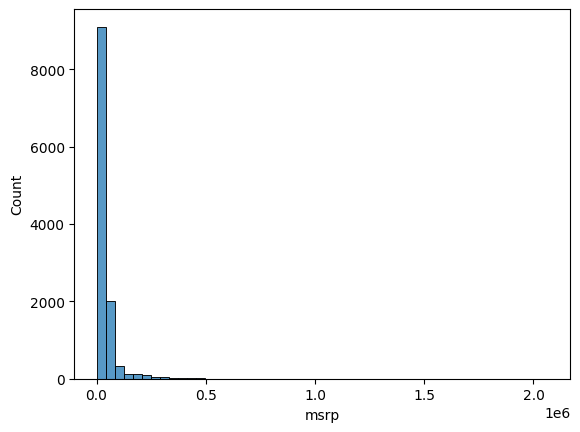

In [15]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

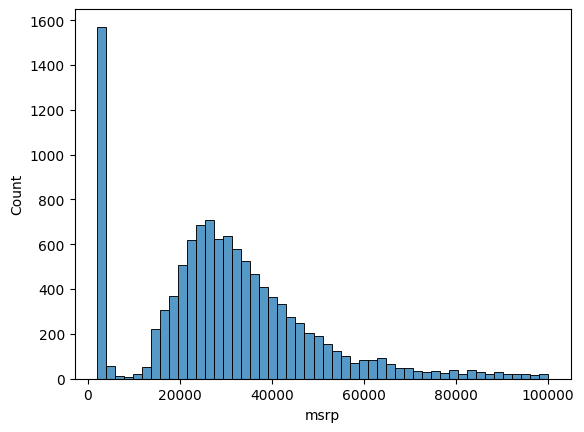

In [16]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [17]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

Valores faltantes

Identificamos qué columnas tienen datos faltantes y cuántos.

## 2.4 Configurando el Framework de Validación

Dividimos los datos en conjuntos de entrenamiento, validación y prueba para evaluar el modelo correctamente.

Visualizamos la distribución del precio en escala logarítmica para obtener una distribución más normal.

Missing values

In [18]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.4 Setting up the validation framework

Let's draw it

In [19]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [20]:
n

11914

In [21]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [22]:
df.iloc[[10, 0, 3, 5]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10,BMW,1 Series,2013,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,39600
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
5,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,31200


In [23]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [24]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,Mazda,Navajo,1994,regular unleaded,160.0,6.0,MANUAL,four wheel drive,2.0,NaN,Compact,2dr SUV,18,14,586,2000
7146,Mazda,Navajo,1994,regular unleaded,160.0,6.0,MANUAL,four wheel drive,2.0,NaN,Compact,2dr SUV,18,14,586,2000
7147,Lincoln,Navigator,2015,regular unleaded,365.0,6.0,AUTOMATIC,four wheel drive,4.0,Luxury,Large,4dr SUV,20,15,61,65055
7148,Lincoln,Navigator,2015,regular unleaded,365.0,6.0,AUTOMATIC,four wheel drive,4.0,Luxury,Large,4dr SUV,19,15,61,67220


In [25]:
idx = np.arange(n)

In [26]:
np.random.seed(2)
np.random.shuffle(idx)

In [27]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [28]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385,14410
6720,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031,19685
5878,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640,19795
11190,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873,2000
4554,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657,56260


In [30]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

## 2.5 Regresión Lineal

Implementamos el modelo de regresión lineal desde cero.

La fórmula de la regresión lineal es:

$$g(x_i) = w_0 + w_1 \cdot x_{i1} + w_2 \cdot x_{i2} + ... + w_n \cdot x_{in}$$

Donde:
- $w_0$ es el término de sesgo (bias)
- $w_1, w_2, ..., w_n$ son los pesos de cada característica
- $x_{i1}, x_{i2}, ..., x_{in}$ son los valores de las características

In [31]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [32]:
len(y_train)

7150

## 2.5 Linear regression

In [33]:
df_train.iloc[10]

make                                 Rolls-Royce
model                     Phantom Drophead Coupe
year                                        2015
engine_fuel_type     premium unleaded (required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      AUTOMATIC
driven_wheels                   rear wheel drive
number_of_doors                              2.0
market_category        Exotic,Luxury,Performance
vehicle_size                               Large
vehicle_style                        Convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
msrp                                      479775
Name: 7557, dtype: object

In [34]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [35]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

## 2.6 Forma Vectorial de la Regresión Lineal

Simplificamos el código usando operaciones vectoriales de NumPy para hacerlo más eficiente.

En lugar de iterar con bucles, usamos el **producto punto** (dot product) para calcular la predicción:

$$g(x_i) = x_i \cdot w = \sum_{j=0}^{n} x_{ij} \cdot w_j$$

In [36]:
linear_regression(xi)

12.312

In [33]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [34]:
np.log1p(222347.2221101062)

np.float64(12.312)

## 2.6 Linear regression vector form

In [37]:
def dot(xi, w):
    n = len(xi)
    
    res = 0.0
    
    for j in range(n):
        res = res + xi[j] * w[j]
    
    return res

In [38]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [39]:
w_new = [w0] + w

In [40]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [41]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [42]:
linear_regression(xi)

12.312

## 2.7 Entrenando el Modelo de Regresión Lineal

Ahora entrenamos el modelo para **encontrar los mejores pesos** automáticamente usando la **Ecuación Normal**.

La fórmula de la Ecuación Normal es:

$$w = (X^T X)^{-1} X^T y$$

Donde:
- $X$ es la matriz de características (con columna de unos para el bias)
- $y$ es el vector de valores objetivo (precios)
- $w$ es el vector de pesos óptimos

In [43]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [44]:
def linear_regression(X):
    return X.dot(w_new)

In [45]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

## 2.7 Training a linear regression model

In [46]:
def train_linear_regression(X, y):
    pass

In [47]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [49]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [50]:
X = np.column_stack([ones, X])
X

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [51]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [52]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [53]:
w0 = w_full[0]
w = w_full[1:]

## 2.8 Modelo Baseline de Precios de Carros

Entrenamos nuestro primer modelo usando solo las características numéricas básicas.

In [54]:
X, y

(array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
        [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
        [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
        [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
        [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
        [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
        [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
        [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
        [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]]),
 [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000])

In [55]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

    

In [57]:
# Reset X a su forma original (sin la columna de unos)
# La función train_linear_regression agrega la columna de unos internamente
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

w0, w = train_linear_regression(X, y)
print(f"w0 = {w0}")
print(f"w = {w}")

w0 = 25844.75405576684
w = [ -16.08906468 -199.47254894   -1.22802883]


## 2.9 RMSE (Root Mean Square Error)

Calculamos el **Error Cuadrático Medio** para evaluar qué tan bien nuestro modelo predice los precios.

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

Donde:
- $y_i$ es el valor real
- $\hat{y}_i$ es la predicción del modelo

In [58]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

## 2.10 Validando el Modelo

Usamos el conjunto de validación para evaluar el rendimiento del modelo en datos que no ha visto durante el entrenamiento.

In [59]:
w0

np.float64(25844.75405576684)

In [60]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [62]:
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [61]:
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

## 2.11 Feature Engineering Simple

Creamos nuevas características para mejorar el modelo. Una de las más importantes es la **edad del vehículo**.

$$age = 2017 - year$$

Los vehículos más nuevos generalmente tienen precios más altos.

<Axes: ylabel='Count'>

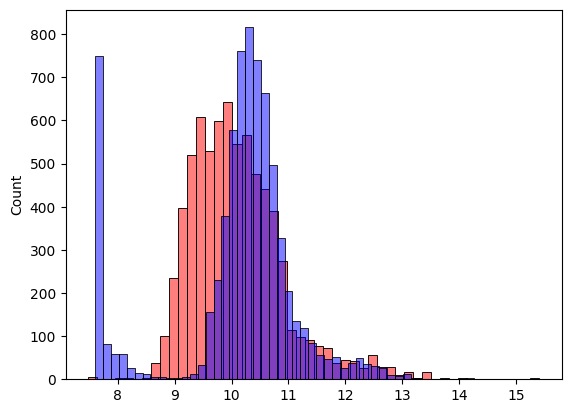

In [57]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)


## 2.12 Variables Categóricas

Las variables categóricas (marca, modelo, tipo de transmisión) no son numéricas, así que usamos **One-Hot Encoding** para convertirlas en columnas binarias (0/1).

Por ejemplo, para la marca BMW creamos una columna `make_bmw` que vale 1 si el carro es BMW y 0 si no.

In [64]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [65]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

## 2.10 Validating the model

In [66]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [71]:
base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [68]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.7616530991301601)

## 2.11 Simple feature engineering

In [69]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

## 2.13 Regularización

Cuando agregamos muchas variables categóricas, la matriz XTX puede volverse **singular** (no invertible) debido a la multicolinealidad.

La **regularización** agrega un término r·I a la matriz para hacerla invertible:

$$w = (X^T X + rI)^{-1} X^T y$$

Donde r es el parámetro de regularización (típicamente un valor pequeño como 0.01).

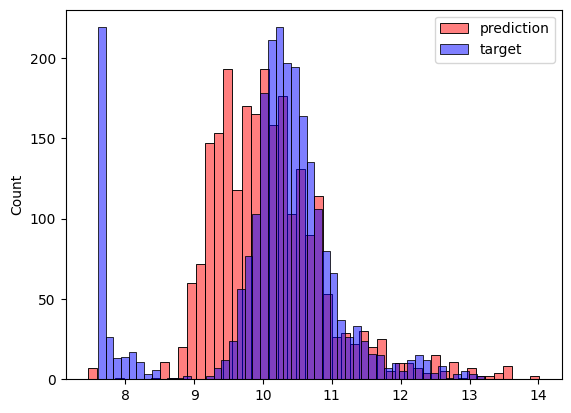

In [70]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

## 2.12 Categorical variables

In [72]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [73]:
categorical

{'make': ['Chevrolet', 'Ford', 'Volkswagen', 'Toyota', 'Dodge'],
 'model': ['Silverado 1500', 'Tundra', 'F-150', 'Sierra 1500', 'Tacoma'],
 'engine_fuel_type': ['regular unleaded',
  'premium unleaded (required)',
  'premium unleaded (recommended)',
  'flex-fuel (unleaded/E85)',
  'diesel'],
 'driven_wheels': ['front wheel drive',
  'rear wheel drive',
  'all wheel drive',
  'four wheel drive'],
 'market_category': ['Crossover',
  'Flex Fuel',
  'Luxury',
  'Hatchback',
  'Luxury,Performance'],
 'vehicle_size': ['Compact', 'Midsize', 'Large'],
 'vehicle_style': ['Sedan',
  '4dr SUV',
  'Coupe',
  'Convertible',
  '4dr Hatchback']}

In [74]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [75]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(40.4553241425115)

In [76]:
w0, w

(np.float64(1742207333371836.0),
 array([-1.22163013e-01,  1.34271900e+01,  2.40970403e+00,  2.34828428e-01,
        -1.04318358e-03, -1.00649194e-01,  3.20719668e+03,  3.20343737e+03,
         3.19875452e+03, -2.51258761e+00,  6.11159030e+00,  2.28754110e+00,
         5.23345526e+01,  4.19028844e-01, -1.01870639e+01, -4.12798858e+01,
        -2.05294085e+00, -2.44662941e+00, -3.61493342e+02, -9.57967147e+01,
        -9.26449216e+01, -9.81777606e+01, -9.73987268e+01, -1.22897522e+02,
        -1.74220733e+15, -1.74220733e+15, -1.74220733e+15, -1.74220733e+15,
         1.13091683e+00,  4.51933586e-01,  1.75752789e-01,  6.96945057e-01,
        -8.96814567e-02,  2.16111775e+01,  3.29174324e+01,  1.84540653e+01,
        -1.44115660e-01, -2.62579827e-02,  1.75913981e-01,  3.65037816e-01,
        -2.90235596e-01]))

## 2.13 Regularization

## 2.14 Ajustando el Modelo

Probamos diferentes valores de regularización (r) para encontrar el que da el mejor RMSE en el conjunto de validación.

In [77]:
y= [1, 2, 3, 1, 2, 3]

In [78]:
XTX = X.T.dot(X)
XTX

array([[ 696471,   44115,  718540],
       [  44115,    7146,  118803],
       [ 718540,  118803, 6359986]])

## 2.15 Usando el Modelo

Ahora entrenamos el modelo final con todos los datos de entrenamiento + validación, y evaluamos en el conjunto de prueba.

In [79]:
XTX_inv

array([[ 3.30686958e+00, -5.39612291e-03, -6.21325581e-02,
        -6.61016816e-04],
       [-5.39612291e-03,  1.11633857e-05,  8.66973393e-05,
         1.08664195e-06],
       [-6.21325581e-02,  8.66973393e-05,  1.46189255e-03,
         8.57849603e-06],
       [-6.61016816e-04,  1.08664195e-06,  8.57849603e-06,
         3.60215866e-07]])

In [80]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]


]

XTX = np.array(XTX)

In [81]:
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [82]:
XTX = XTX + 0.01 * np.eye(3)

## 2.16 Próximos Pasos

- Incluir solo las 5 características principales. ¿Qué pasa si incluimos 10?

**Otros proyectos:**
- Predecir el precio de una casa - dataset de Boston
- https://archive.ics.uci.edu/ml/datasets.php?task=reg
- https://archive.ics.uci.edu/ml/datasets/Student+Performance

## 2.17 Resumen

- **EDA**: Exploración de datos, identificación de valores faltantes
- **Distribución de la variable objetivo**: cola larga → distribución en forma de campana
- **Framework de validación**: división train/val/test (nos ayudó a detectar problemas)
- **Ecuación Normal**: no es magia, es matemática
- **Implementación con NumPy**
- **RMSE** para validar nuestro modelo
- **Feature Engineering**: edad, variables categóricas
- **Regularización** para combatir la inestabilidad numérica


* Hemos incluido solo 5 features. ¿Qué pasa si incluimos 10?

Otros proyectos

* Predict the price of a house - e.g. boston dataset
* https://archive.ics.uci.edu/ml/datasets.php?task=reg
* https://archive.ics.uci.edu/ml/datasets/Student+Performance